In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

df_alpha = pd.read_csv("../data/processed/regime_alpha_dataset.csv")

df = df_alpha.copy()

df["future_error"] = df["outcome"] - df["final_probability"]

df["abs_mispricing"] = df["mispricing"].abs()


df = df_alpha.copy()

df["future_error"] = df["outcome"] - df["final_probability"]

df["abs_mispricing"] = df["mispricing"].abs()

df[["market_id","market_regime","outcome","final_probability", "bayesian_fair_probability", "mispricing",
    "future_error"]].head()

,market_id,market_regime,outcome,final_probability,bayesian_fair_probability,mispricing,future_error
0,248594,Information Processing,0,0.020,0.038462,0.018462,-0.020
1,249778,Anchored / Noisy,1,0.550,0.600000,0.050000,0.450
2,250474,Anchored / Noisy,0,0.360,0.333333,-0.026667,-0.360
3,251025,Information Processing,1,0.995,0.900000,-0.095000,0.005
4,251027,Anchored / Noisy,1,0.825,0.666667,-0.158333,0.175


In [4]:
# Bayesian Original
df["pred_original"] = np.where(df["mispricing"] > 0,1,0)
# conrrarian
df["pred_contrarian"] = np.where(df["mispricing"] > 0,0,1)
# Regime-Aware
df["pred_regime_aware"] = np.where(df["market_regime"] == "Information Processing",df["pred_contrarian"],df["pred_original"])
# accuracy global
strategies = ["pred_original","pred_contrarian","pred_regime_aware"]

performance = []

for strategy in strategies:
    performance.append({
        "strategy": strategy,
        "accuracy": accuracy_score(df["outcome"], df[strategy]),
        "precision": precision_score(df["outcome"], df[strategy], zero_division=0),
        "recall": recall_score(df["outcome"], df[strategy], zero_division=0),
        "f1": f1_score(df["outcome"], df[strategy], zero_division=0)
    })

performance_df = pd.DataFrame(performance)
performance_df

,strategy,accuracy,precision,recall,f1
0,pred_original,0.209302,0.115385,0.214286,0.150000
1,pred_contrarian,0.790698,0.647059,0.785714,0.709677
2,pred_regime_aware,0.860465,0.722222,0.928571,0.812500


In [5]:
# Evaluate by regime
regime_performance = []

for regime in df["market_regime"].unique():
    subset = df[df["market_regime"] == regime]

    for strategy in strategies:
        regime_performance.append({
            "market_regime": regime,
            "strategy": strategy,
            "n_markets": len(subset),
            "accuracy": accuracy_score(subset["outcome"], subset[strategy]),
            "precision": precision_score(subset["outcome"], subset[strategy], zero_division=0),
            "recall": recall_score(subset["outcome"], subset[strategy], zero_division=0),
            "f1": f1_score(subset["outcome"], subset[strategy], zero_division=0)
        })

regime_performance_df = pd.DataFrame(regime_performance)
regime_performance_df

,market_regime,strategy,n_markets,accuracy,precision,recall,f1
0,Information Processing,pred_original,32,0.062500,0.000000,0.00,0.000000
1,Information Processing,pred_contrarian,32,0.937500,0.833333,1.00,0.909091
2,Information Processing,pred_regime_aware,32,0.937500,0.833333,1.00,0.909091
3,Anchored / Noisy,pred_original,11,0.636364,0.500000,0.75,0.600000
4,Anchored / Noisy,pred_contrarian,11,0.363636,0.200000,0.25,0.222222
5,Anchored / Noisy,pred_regime_aware,11,0.636364,0.500000,0.75,0.600000


In [6]:
# Simple results matrix
regime_performance_df.pivot(index="market_regime",columns="strategy",values="accuracy")

strategy,pred_contrarian,pred_original,pred_regime_aware
market_regime,,,
Anchored / Noisy,0.363636,0.636364,0.636364
Information Processing,0.937500,0.062500,0.937500


In [7]:
# Classification report of the main strategy
print(classification_report(df["outcome"],df["pred_regime_aware"],zero_division=0))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89        29
           1       0.72      0.93      0.81        14

    accuracy                           0.86        43
   macro avg       0.84      0.88      0.85        43
weighted avg       0.88      0.86      0.86        43



Bayesian Mispricing does contain information, but only when interpreted conditionally to the regime?

In [11]:
#  build the P&L
def trade_pnl(probability, prediction, outcome):
    if prediction == 1:
        return outcome - probability
    else:
        return probability - outcome

strategies = [
    "pred_original",
    "pred_contrarian",
    "pred_regime_aware"
]

for strategy in strategies:

    df[f"pnl_{strategy}"] = df.apply(lambda row: trade_pnl(row["final_probability"],row[strategy],row["outcome"]),axis=1)

# resume 
pnl_results = []

for strategy in strategies:

    pnl_col = f"pnl_{strategy}"
    pnl_results.append({"strategy": strategy,"total_pnl": df[pnl_col].sum(),"avg_trade": df[pnl_col].mean(),"win_rate": (df[pnl_col] > 0).mean(),
        "n_trades": len(df)})

pnl_results = pd.DataFrame(pnl_results)

pnl_results


,strategy,total_pnl,avg_trade,win_rate,n_trades
0,pred_original,1.2255,0.028500,0.209302,43
1,pred_contrarian,-1.2255,-0.028500,0.790698,43
2,pred_regime_aware,3.3525,0.077965,0.860465,43


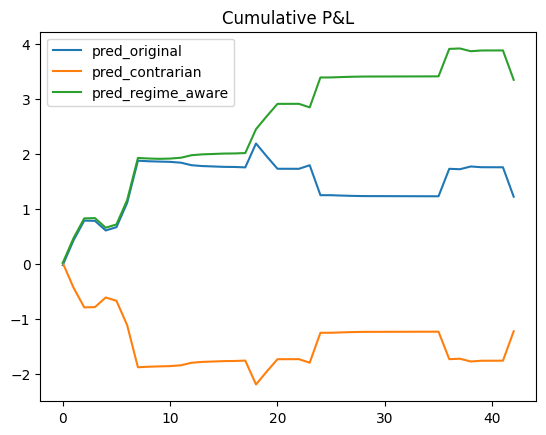

In [9]:
# Equity Curve
for strategy in strategies:
    pnl_col = f"pnl_{strategy}"
    equity = df[pnl_col].cumsum()
    plt.plot(equity,label=strategy)

plt.legend()
plt.title("Cumulative P&L")
plt.show()

Regime-aware signals substantially improve directional prediction accuracy relative to naive Bayesian mispricing. However, economic profitability cannot yet be assessed because signals are evaluated using probabilities observed near market resolution.